In [ ]:
# Phase 0 

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS_SYN = ROOT / "results_n2000"
RESULTS_NAT = ROOT / "natural_abstraction" / "results_natural"
FIG_DIR = ROOT / "figures_analysis"
FIG_DIR.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Synthetic dir:", RESULTS_SYN.exists(), RESULTS_SYN)
print("Natural dir:", RESULTS_NAT.exists(), RESULTS_NAT)
print("Figure dir:", FIG_DIR)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "grid.alpha": 0.3
})

Project root: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project
Synthetic dir: True c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\results_n2000
Natural dir: True c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\natural_abstraction\results_natural
Figure dir: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\figures_analysis


In [2]:
# --- synthetic summaries ---
sum_app_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_openclip.csv")
sum_geo_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_openclip.csv")
sum_app_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_efficientnet.csv")
sum_geo_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_efficientnet.csv")

drift_clip_app = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_appearance.csv")
drift_clip_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_geometry.csv")
drift_eff_app = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_appearance.csv")
drift_eff_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_geometry.csv")
drift_dino_app = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_appearance.csv")
drift_dino_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_geometry.csv")

fail_app_clip = pd.read_csv(RESULTS_SYN / "failure_corruptions_appearance_openclip.csv")
fail_geo_clip = pd.read_csv(RESULTS_SYN / "failure_corruptions_geometry_openclip.csv")
fail_app_eff = pd.read_csv(RESULTS_SYN / "failure_corruptions_appearance_efficientnet.csv")
fail_geo_eff = pd.read_csv(RESULTS_SYN / "failure_corruptions_geometry_efficientnet.csv")

# --- natural per-image baselines ---
nat_clip_raw = pd.read_csv(RESULTS_NAT / "baseline_natural_openclip.csv")
nat_eff_raw = pd.read_csv(RESULTS_NAT / "baseline_natural_efficientnet.csv")

# --- natural summaries ---
nat_clip_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class.csv")
nat_clip_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_subtype.csv")
nat_clip_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class_subtype.csv")

nat_eff_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_class.csv")
nat_eff_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_subtype.csv")
nat_eff_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_class_subtype.csv")

# --- natural drift ---
nat_clip_drift_img = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_per_image.csv")
nat_clip_drift_class = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class.csv")
nat_clip_drift_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_subtype.csv")
nat_clip_drift_class_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class_subtype.csv")

nat_dino_drift_img = pd.read_csv(RESULTS_NAT / "dino_natural_drift_per_image.csv")
nat_dino_drift_class = pd.read_csv(RESULTS_NAT / "dino_natural_drift_by_class.csv")
nat_dino_drift_subtype = pd.read_csv(RESULTS_NAT / "dino_natural_drift_by_subtype.csv")
nat_dino_drift_class_subtype = pd.read_csv(RESULTS_NAT / "dino_natural_drift_by_class_subtype.csv")

# --- confusion ---
conf_overall = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_overall.csv", index_col=0)
conf_abstract = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_abstract.csv", index_col=0)
conf_cartoon = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_cartoon.csv", index_col=0)
conf_painting = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_painting.csv", index_col=0)
conf_real = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_real.csv", index_col=0)
conf_sketch = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_sketch.csv", index_col=0)

print("Loaded all analysis tables.")

Loaded all analysis tables.


In [3]:
SUBTYPE_ORDER = ["real", "painting", "cartoon", "sketch", "abstract"]
SUBTYPE_TO_LEVEL = {k: i for i, k in enumerate(SUBTYPE_ORDER)}

CLASS_ORDER = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def order_subtypes(df, subtype_col="subtype"):
    d = df.copy()
    d["level"] = d[subtype_col].map(SUBTYPE_TO_LEVEL)
    return d.sort_values("level")

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches="tight")
    plt.show()

def lineplot_by_transform(df, ycol, title, ylabel, fname=None):
    plt.figure()
    for t in sorted(df["transform"].unique()):
        sub = df[df["transform"] == t].sort_values("level")
        plt.plot(sub["level"], sub[ycol], marker="o", label=t)
    plt.grid(True)
    plt.xlabel("Severity Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title="Transformation")
    if fname:
        savefig(fname)
    else:
        plt.show()

def barplot(df, xcol, ycol, title, ylabel, rotation=30, fname=None, order=None):
    d = df.copy()
    if order is not None:
        d[xcol] = pd.Categorical(d[xcol], categories=order, ordered=True)
        d = d.sort_values(xcol)
    plt.figure()
    plt.bar(d[xcol], d[ycol])
    plt.grid(axis="y")
    plt.xlabel("")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=rotation)
    if fname:
        savefig(fname)
    else:
        plt.show()

def heatmap_from_pivot(mat, title, fname=None):
    plt.figure(figsize=(8, 5))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=45, ha="right")
    plt.yticks(range(len(mat.index)), mat.index)
    plt.title(title)
    if fname:
        savefig(fname)
    else:
        plt.show()

In [ ]:
# Phase 1 

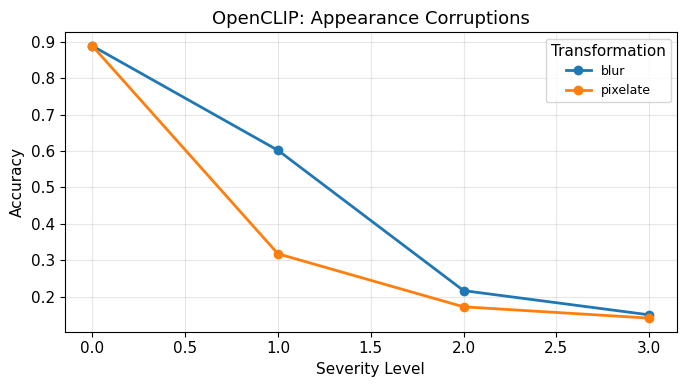

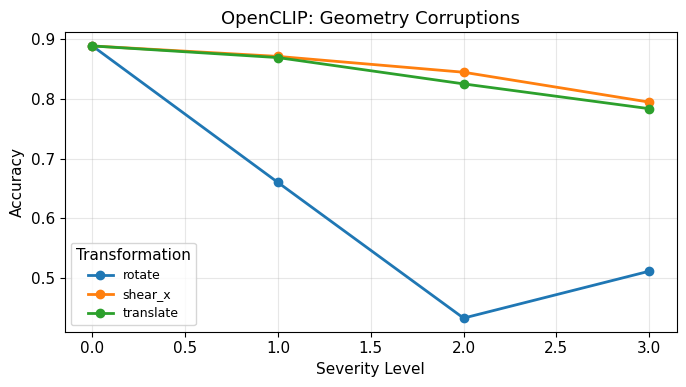

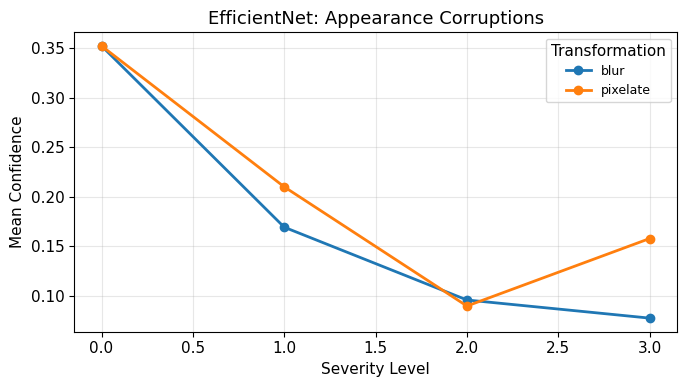

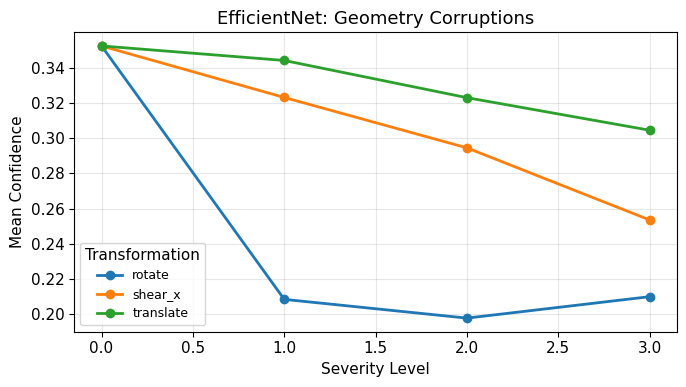

In [4]:
lineplot_by_transform(
    sum_app_clip, "accuracy",
    "OpenCLIP: Appearance Corruptions",
    "Accuracy",
    "synthetic_openclip_appearance_accuracy.png"
)

lineplot_by_transform(
    sum_geo_clip, "accuracy",
    "OpenCLIP: Geometry Corruptions",
    "Accuracy",
    "synthetic_openclip_geometry_accuracy.png"
)

lineplot_by_transform(
    sum_app_eff, "mean_confidence",
    "EfficientNet: Appearance Corruptions",
    "Mean Confidence",
    "synthetic_effnet_appearance_confidence.png"
)

lineplot_by_transform(
    sum_geo_eff, "mean_confidence",
    "EfficientNet: Geometry Corruptions",
    "Mean Confidence",
    "synthetic_effnet_geometry_confidence.png"
)

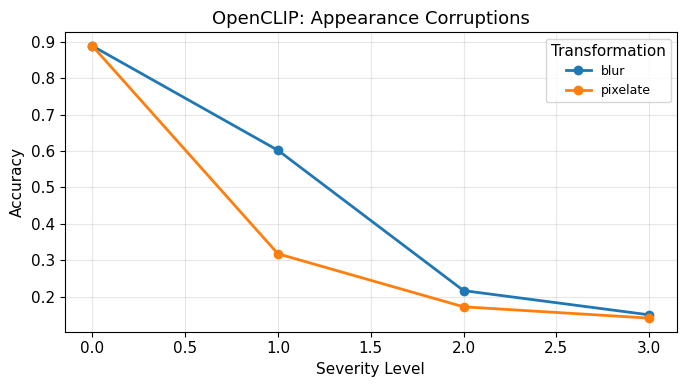

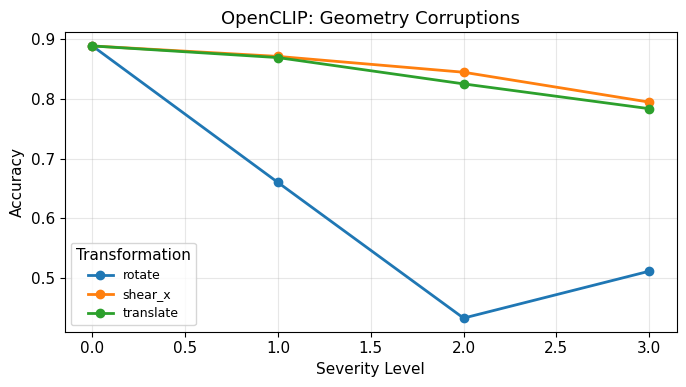

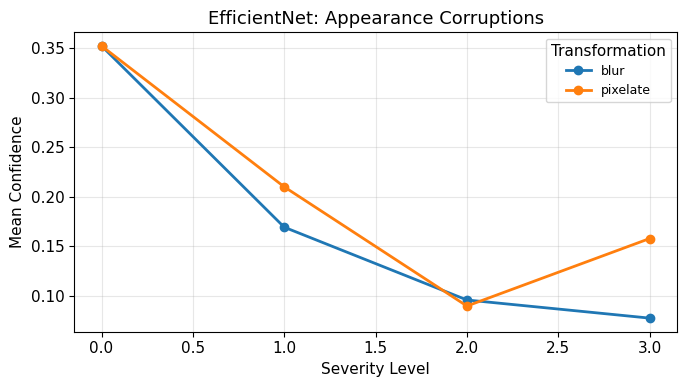

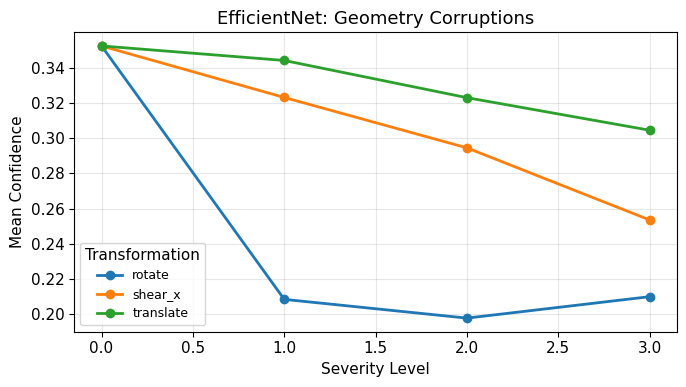

In [5]:
lineplot_by_transform(
    sum_app_clip, "accuracy",
    "OpenCLIP: Appearance Corruptions",
    "Accuracy",
    "synthetic_openclip_appearance_accuracy.png"
)

lineplot_by_transform(
    sum_geo_clip, "accuracy",
    "OpenCLIP: Geometry Corruptions",
    "Accuracy",
    "synthetic_openclip_geometry_accuracy.png"
)

lineplot_by_transform(
    sum_app_eff, "mean_confidence",
    "EfficientNet: Appearance Corruptions",
    "Mean Confidence",
    "synthetic_effnet_appearance_confidence.png"
)

lineplot_by_transform(
    sum_geo_eff, "mean_confidence",
    "EfficientNet: Geometry Corruptions",
    "Mean Confidence",
    "synthetic_effnet_geometry_confidence.png"
)

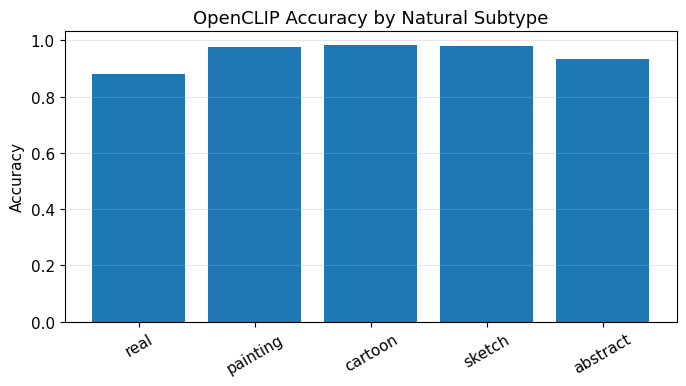

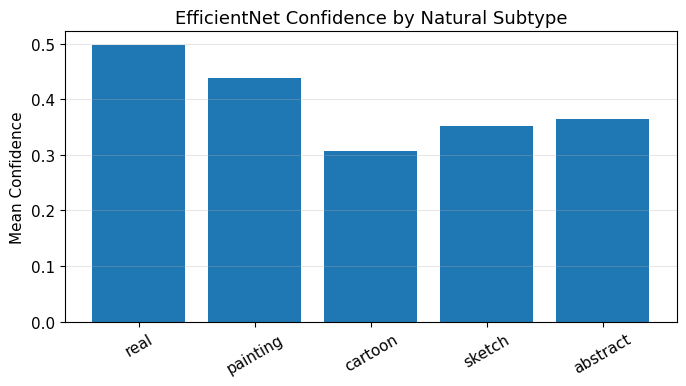

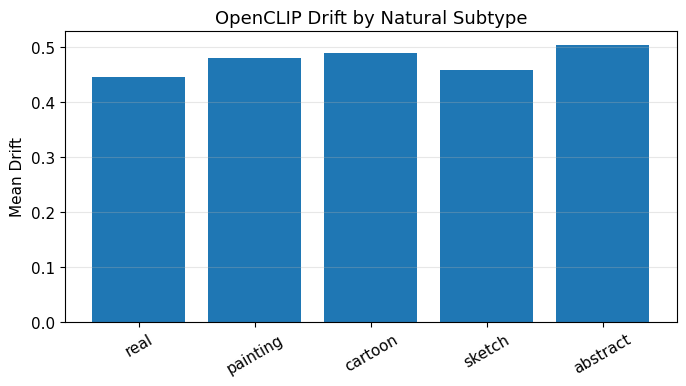

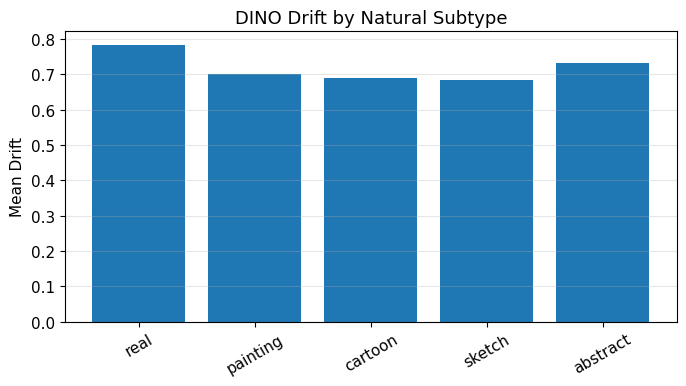

In [6]:
barplot(
    nat_clip_subtype, "subtype", "accuracy",
    "OpenCLIP Accuracy by Natural Subtype",
    "Accuracy",
    fname="natural_openclip_subtype_accuracy.png",
    order=SUBTYPE_ORDER
)

barplot(
    nat_eff_subtype, "subtype", "mean_confidence",
    "EfficientNet Confidence by Natural Subtype",
    "Mean Confidence",
    fname="natural_effnet_subtype_confidence.png",
    order=SUBTYPE_ORDER
)

barplot(
    nat_clip_drift_subtype, "subtype", "mean_drift",
    "OpenCLIP Drift by Natural Subtype",
    "Mean Drift",
    fname="natural_openclip_subtype_drift.png",
    order=SUBTYPE_ORDER
)

barplot(
    nat_dino_drift_subtype, "subtype", "mean_drift",
    "DINO Drift by Natural Subtype",
    "Mean Drift",
    fname="natural_dino_subtype_drift.png",
    order=SUBTYPE_ORDER
)

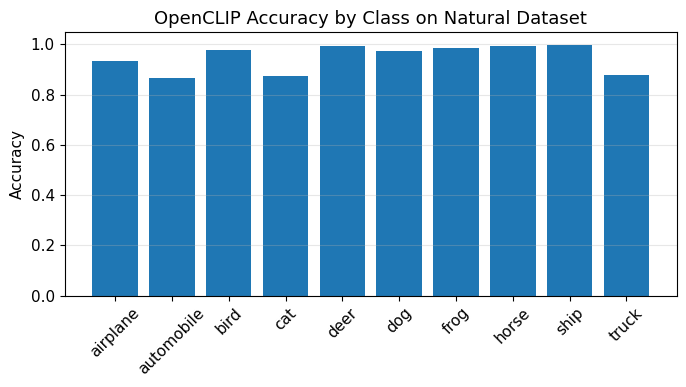

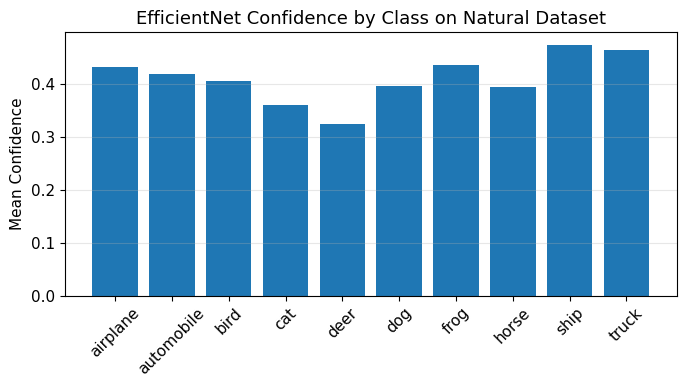

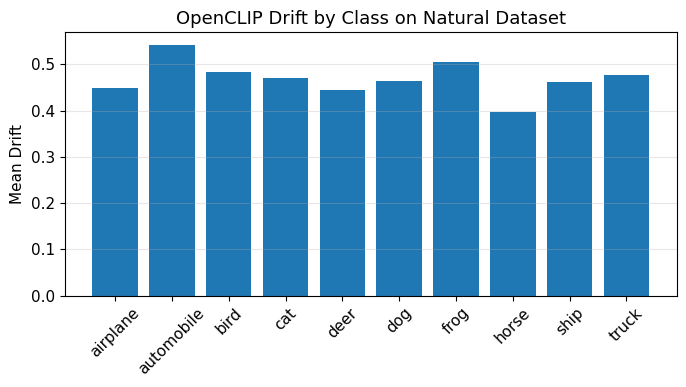

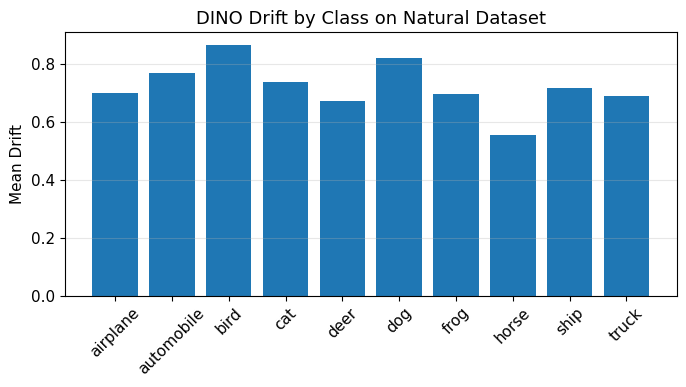

In [7]:
barplot(
    nat_clip_class, "true_label_name", "accuracy",
    "OpenCLIP Accuracy by Class on Natural Dataset",
    "Accuracy",
    rotation=45,
    fname="natural_openclip_class_accuracy.png",
    order=CLASS_ORDER
)

barplot(
    nat_eff_class, "true_label_name", "mean_confidence",
    "EfficientNet Confidence by Class on Natural Dataset",
    "Mean Confidence",
    rotation=45,
    fname="natural_effnet_class_confidence.png",
    order=CLASS_ORDER
)

barplot(
    nat_clip_drift_class, "true_label_name", "mean_drift",
    "OpenCLIP Drift by Class on Natural Dataset",
    "Mean Drift",
    rotation=45,
    fname="natural_openclip_class_drift.png",
    order=CLASS_ORDER
)

barplot(
    nat_dino_drift_class, "true_label_name", "mean_drift",
    "DINO Drift by Class on Natural Dataset",
    "Mean Drift",
    rotation=45,
    fname="natural_dino_class_drift.png",
    order=CLASS_ORDER
)

In [ ]:
# Phase 3 

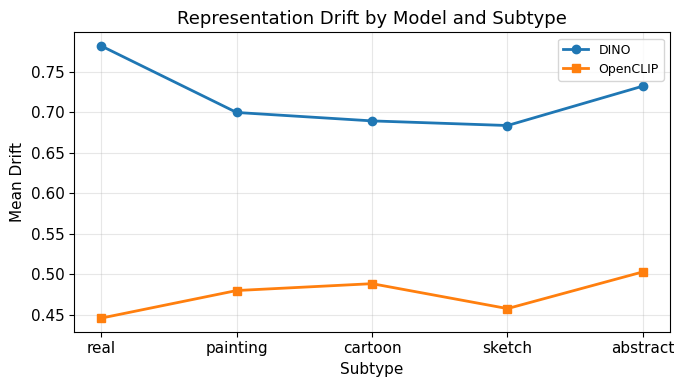

In [8]:
dino_sub = order_subtypes(nat_dino_drift_subtype)
clip_sub = order_subtypes(nat_clip_drift_subtype)

plt.figure()
plt.plot(dino_sub["subtype"], dino_sub["mean_drift"], marker="o", label="DINO")
plt.plot(clip_sub["subtype"], clip_sub["mean_drift"], marker="s", label="OpenCLIP")
plt.grid(True)
plt.xlabel("Subtype")
plt.ylabel("Mean Drift")
plt.title("Representation Drift by Model and Subtype")
plt.legend()
savefig("natural_dino_vs_openclip_subtype_drift.png")

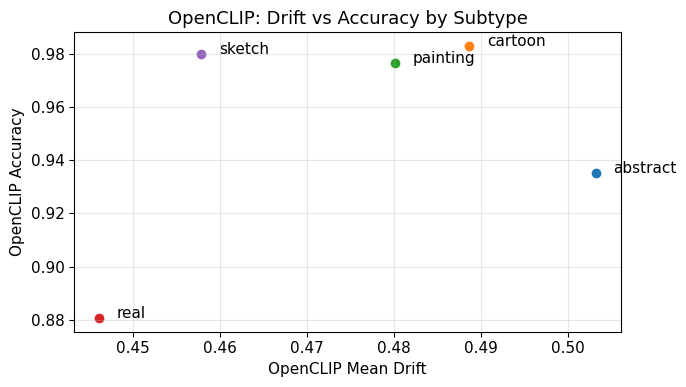

In [9]:
clip_merge = nat_clip_subtype.merge(
    nat_clip_drift_subtype[["subtype", "mean_drift"]],
    on="subtype",
    suffixes=("_acc", "_drift")
)

plt.figure()
for _, row in clip_merge.iterrows():
    plt.scatter(row["mean_drift"], row["accuracy"])
    plt.text(row["mean_drift"] + 0.002, row["accuracy"], row["subtype"])
plt.grid(True)
plt.xlabel("OpenCLIP Mean Drift")
plt.ylabel("OpenCLIP Accuracy")
plt.title("OpenCLIP: Drift vs Accuracy by Subtype")
savefig("natural_openclip_drift_vs_accuracy_subtype.png")

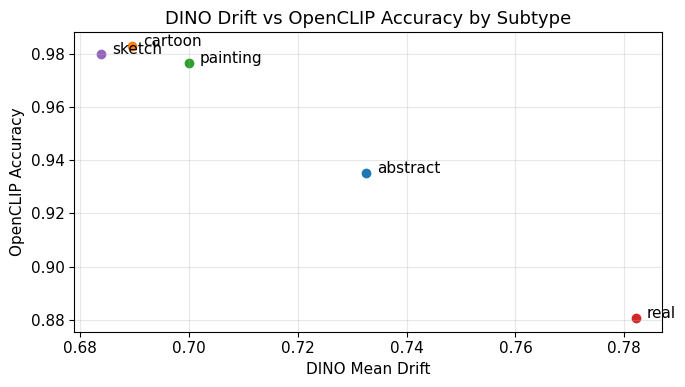

In [10]:
dino_clip_merge = nat_clip_subtype.merge(
    nat_dino_drift_subtype[["subtype", "mean_drift"]],
    on="subtype"
)

plt.figure()
for _, row in dino_clip_merge.iterrows():
    plt.scatter(row["mean_drift"], row["accuracy"])
    plt.text(row["mean_drift"] + 0.002, row["accuracy"], row["subtype"])
plt.grid(True)
plt.xlabel("DINO Mean Drift")
plt.ylabel("OpenCLIP Accuracy")
plt.title("DINO Drift vs OpenCLIP Accuracy by Subtype")
savefig("natural_dino_drift_vs_openclip_accuracy.png")

In [ ]:
# Phase 3 


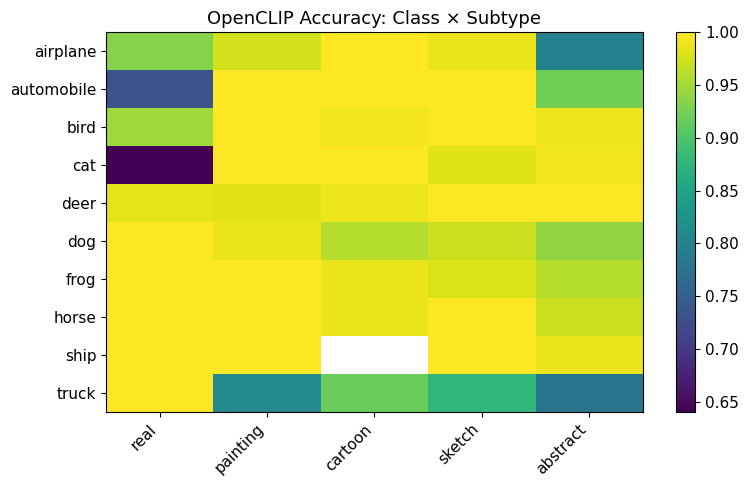

In [11]:
acc_heat = nat_clip_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="accuracy"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    acc_heat,
    "OpenCLIP Accuracy: Class × Subtype",
    "heatmap_openclip_accuracy_class_subtype.png"
)

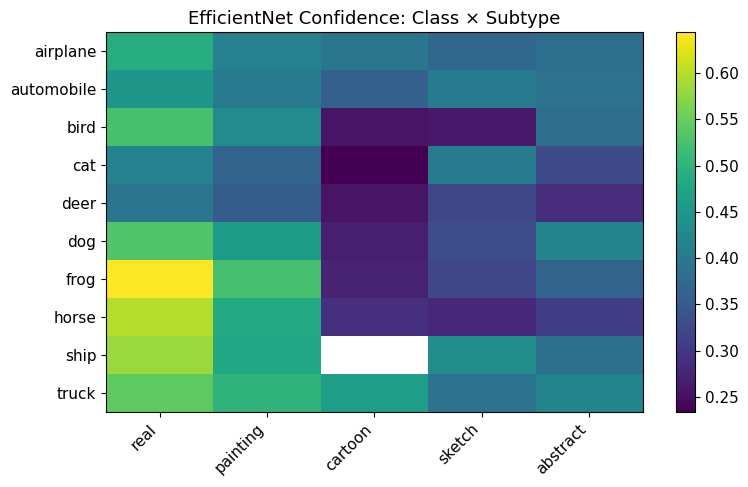

In [12]:
eff_heat = nat_eff_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="mean_confidence"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    eff_heat,
    "EfficientNet Confidence: Class × Subtype",
    "heatmap_effnet_confidence_class_subtype.png"
)

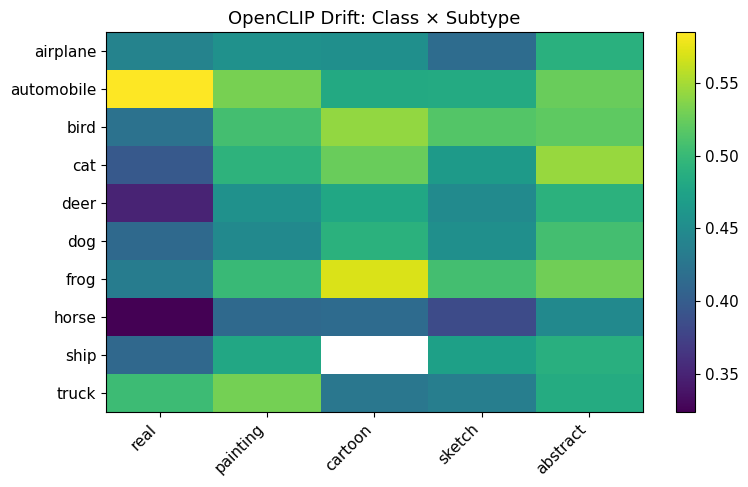

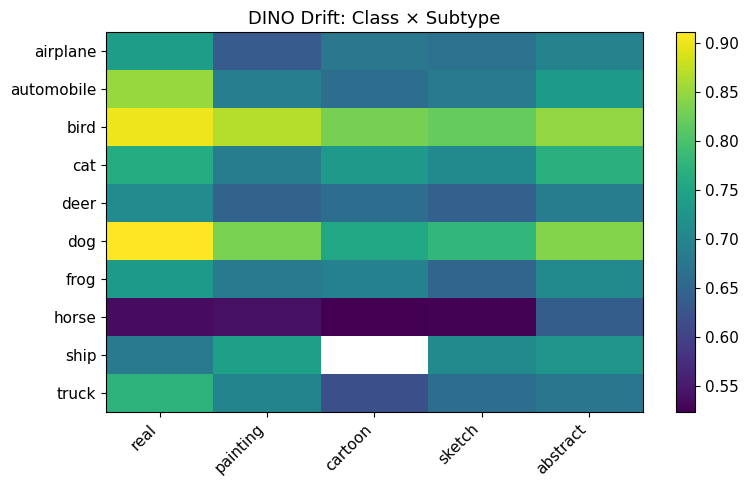

In [13]:
clip_drift_heat = nat_clip_drift_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="mean_drift"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    clip_drift_heat,
    "OpenCLIP Drift: Class × Subtype",
    "heatmap_openclip_drift_class_subtype.png"
)

dino_drift_heat = nat_dino_drift_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="mean_drift"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    dino_drift_heat,
    "DINO Drift: Class × Subtype",
    "heatmap_dino_drift_class_subtype.png"
)

In [ ]:
# Phase 4 

###  Confusion Structure 

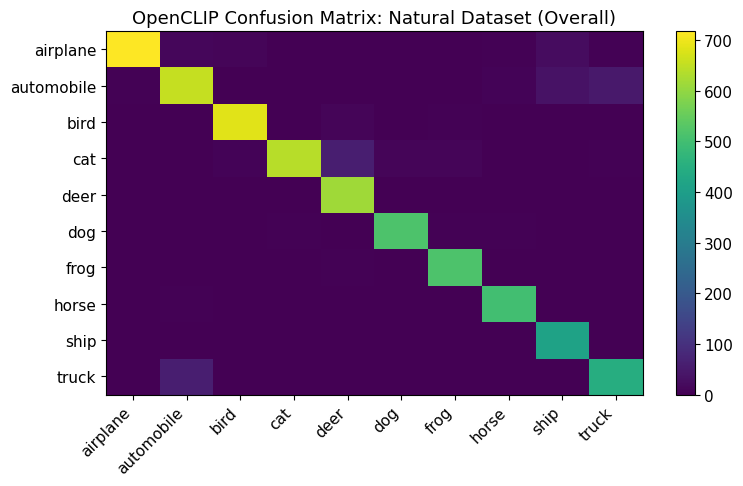

In [14]:
heatmap_from_pivot(
    conf_overall.reindex(index=CLASS_ORDER, columns=CLASS_ORDER),
    "OpenCLIP Confusion Matrix: Natural Dataset (Overall)",
    "confusion_overall_openclip_natural.png"
)

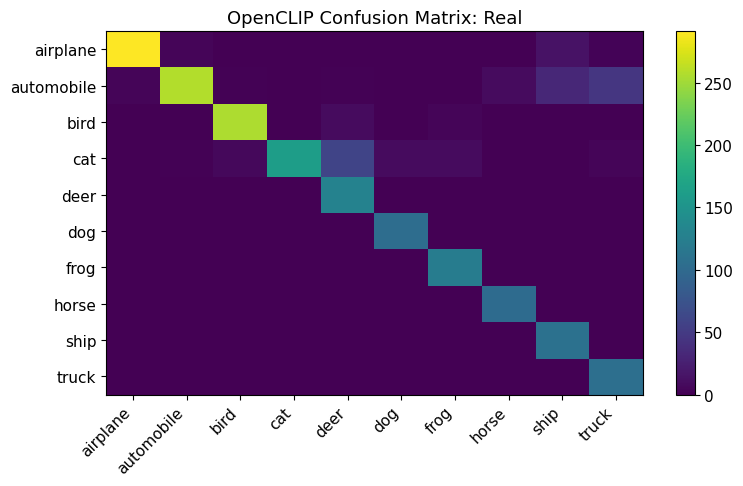

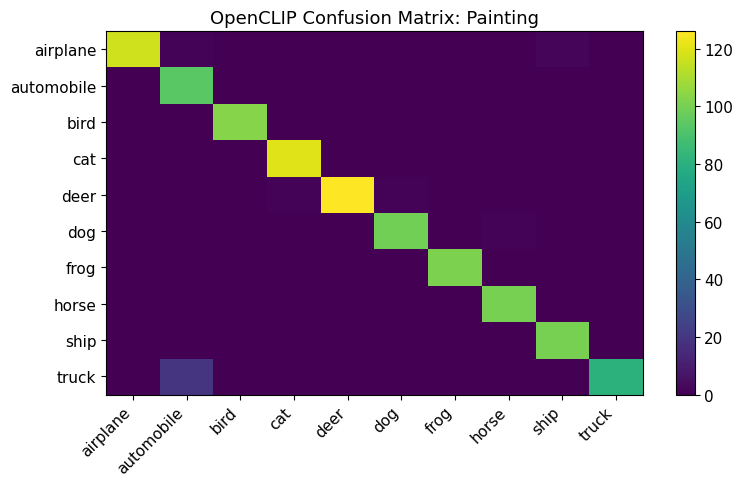

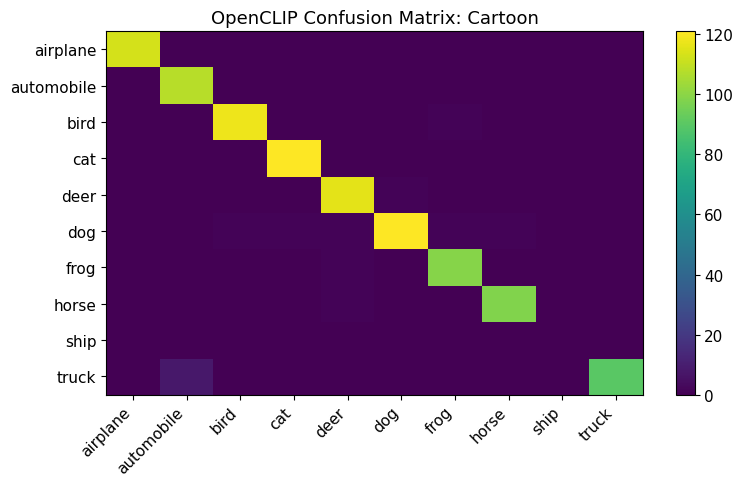

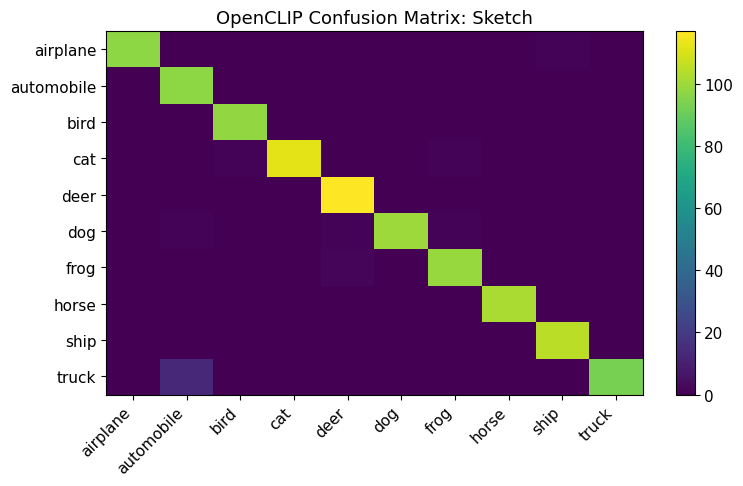

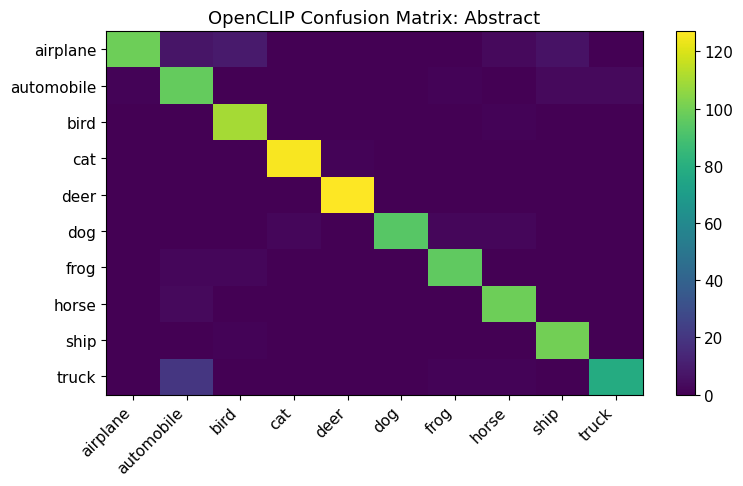

In [15]:
conf_maps = {
    "real": conf_real,
    "painting": conf_painting,
    "cartoon": conf_cartoon,
    "sketch": conf_sketch,
    "abstract": conf_abstract,
}

for subtype, mat in conf_maps.items():
    heatmap_from_pivot(
        mat.reindex(index=CLASS_ORDER, columns=CLASS_ORDER),
        f"OpenCLIP Confusion Matrix: {subtype.title()}",
        f"confusion_openclip_{subtype}.png"
    )

In [16]:
def top_confusions(conf_df, top_k=15):
    rows = []
    for true_label in conf_df.index:
        for pred_label in conf_df.columns:
            if true_label == pred_label:
                continue
            val = conf_df.loc[true_label, pred_label]
            if val > 0:
                rows.append((true_label, pred_label, val))
    out = pd.DataFrame(rows, columns=["true", "pred", "count"])
    return out.sort_values("count", ascending=False).head(top_k)

top_confusions(conf_overall, top_k=20)

,true,pred,count
18,cat,deer,61
38,truck,automobile,60
11,automobile,truck,49
10,automobile,ship,35
3,airplane,ship,23
0,airplane,automobile,12
20,cat,frog,10
12,bird,deer,9
1,airplane,bird,9
19,cat,dog,9


In [ ]:
# Phase 5 

### Synthetic <---> Natural Bridge


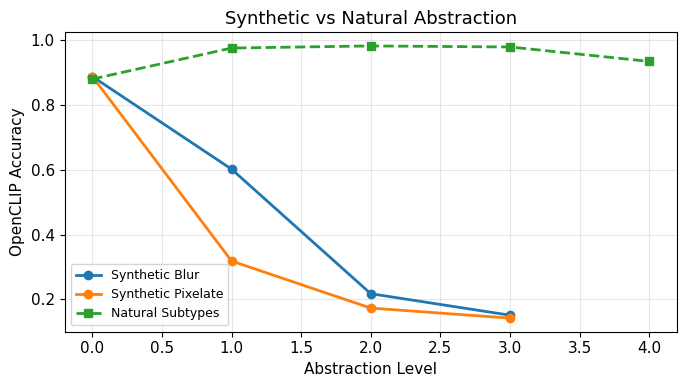

In [17]:
nat_cross = order_subtypes(nat_clip_subtype)

syn_blur = sum_app_clip[sum_app_clip["transform"] == "blur"].sort_values("level")
syn_pix = sum_app_clip[sum_app_clip["transform"] == "pixelate"].sort_values("level")

plt.figure()
plt.plot(syn_blur["level"], syn_blur["accuracy"], marker="o", label="Synthetic Blur")
plt.plot(syn_pix["level"], syn_pix["accuracy"], marker="o", label="Synthetic Pixelate")
plt.plot(nat_cross["level"], nat_cross["accuracy"], marker="s", linestyle="--", label="Natural Subtypes")
plt.grid(True)
plt.xlabel("Abstraction Level")
plt.ylabel("OpenCLIP Accuracy")
plt.title("Synthetic vs Natural Abstraction")
plt.legend()
savefig("bridge_synthetic_vs_natural_openclip_accuracy.png")

In [18]:
def closest_level(syn_df, target_val, ycol):
    syn_df = syn_df.copy()
    syn_df["dist"] = (syn_df[ycol] - target_val).abs()
    return syn_df.sort_values("dist").iloc[0][["level", ycol, "dist"]]

bridge_rows = []
for _, row in nat_cross.iterrows():
    blur_match = closest_level(syn_blur, row["accuracy"], "accuracy")
    pix_match = closest_level(syn_pix, row["accuracy"], "accuracy")
    bridge_rows.append({
        "subtype": row["subtype"],
        "natural_accuracy": row["accuracy"],
        "closest_blur_level": blur_match["level"],
        "closest_pixelate_level": pix_match["level"],
    })

bridge_table = pd.DataFrame(bridge_rows)
bridge_table

,subtype,natural_accuracy,closest_blur_level,closest_pixelate_level
0,real,0.880581,0,0
1,painting,0.976548,0,0
2,cartoon,0.983017,0,0
3,sketch,0.979827,0,0
4,abstract,0.935278,0,0


In [22]:
CUMULATIVE_SETS = [
    ["real"],
    ["real", "painting"],
    ["real", "painting", "cartoon"],
    ["real", "painting", "cartoon", "sketch"],
    ["real", "painting", "cartoon", "sketch", "abstract"],
]

rows = []
for i, subset in enumerate(CUMULATIVE_SETS):
    sub_df = nat_clip_raw[nat_clip_raw["subtype"].isin(subset)]
    rows.append({
        "step": i + 1,
        "included": " + ".join(subset),
        "accuracy": sub_df["correct"].mean(),
        "mean_confidence": sub_df["confidence"].mean(),
        "n": len(sub_df),
    })

cum_clip = pd.DataFrame(rows)
cum_clip



,step,included,accuracy,mean_confidence,n
0,1,real,0.880581,0.111872,1859
1,2,real + painting,0.915556,0.112575,2925
2,3,real + painting + cartoon,0.932756,0.113144,3926
3,4,real + painting + cartoon + sketch,0.942621,0.113373,4967
4,5,real + painting + cartoon + sketch + abstract,0.941293,0.113057,6064


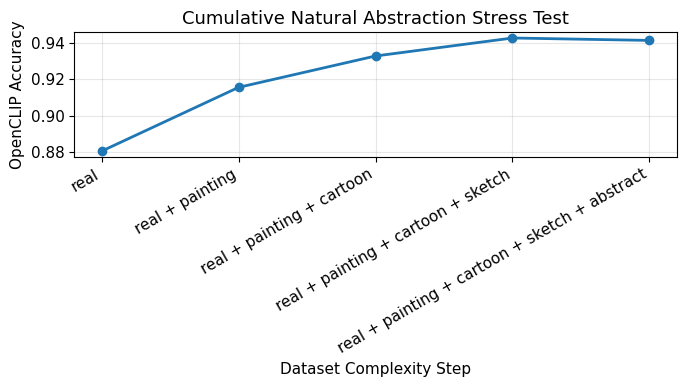

In [21]:
plt.figure()
plt.plot(cum_clip["step"], cum_clip["accuracy"], marker="o")
plt.grid(True)
plt.xlabel("Dataset Complexity Step")
plt.ylabel("OpenCLIP Accuracy")
plt.title("Cumulative Natural Abstraction Stress Test")
plt.xticks(cum_clip["step"], cum_clip["included"], rotation=30, ha="right")
savefig("stress_test_cumulative_openclip_accuracy.png")

In [ ]:
# Path 7 

### Hard Examples and Qualitative Analysis 

In [23]:
hard_clip = nat_clip_raw.merge(
    nat_clip_drift_img[["image_id", "meaningless_placeholder"]] if False else nat_clip_drift_img,
    on=["image_id", "image_path", "true_label", "true_label_name", "subtype"],
    how="inner"
)

In [24]:
hardest_drift = nat_clip_drift_img.sort_values("drift_from_cifar_prototype", ascending=False).head(50)
hardest_clip_lowconf = nat_clip_raw.sort_values("confidence").head(50)

hardest_drift.head(20)
hardest_clip_lowconf.head(20)

,model,dataset,image_id,image_path,true_label,true_label_name,subtype,pred_label,pred_label_name,confidence,correct
113,openclip_vit_b_32,natural_gallery,113,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract,2,bird,0.101135,0
3726,openclip_vit_b_32,natural_gallery,3726,C:\Users\Melvi\Downloads\research_seminar\visi...,5,dog,cartoon,2,bird,0.101135,0
5582,openclip_vit_b_32,natural_gallery,5582,C:\Users\Melvi\Downloads\research_seminar\visi...,9,truck,abstract,6,frog,0.101184,0
1420,openclip_vit_b_32,natural_gallery,1420,C:\Users\Melvi\Downloads\research_seminar\visi...,1,automobile,real,2,bird,0.101278,0
5,openclip_vit_b_32,natural_gallery,5,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract,8,ship,0.101473,0
43,openclip_vit_b_32,natural_gallery,43,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract,7,horse,0.101546,0
2680,openclip_vit_b_32,natural_gallery,2680,C:\Users\Melvi\Downloads\research_seminar\visi...,3,cat,real,4,deer,0.101791,0
4160,openclip_vit_b_32,natural_gallery,4160,C:\Users\Melvi\Downloads\research_seminar\visi...,6,frog,abstract,1,automobile,0.101850,0
1114,openclip_vit_b_32,natural_gallery,1114,C:\Users\Melvi\Downloads\research_seminar\visi...,1,automobile,real,1,automobile,0.101858,1
2679,openclip_vit_b_32,natural_gallery,2679,C:\Users\Melvi\Downloads\research_seminar\visi...,3,cat,real,2,bird,0.101877,0


In [ ]:
# Phase 8 

### Statistical Validation 

In [25]:
def bootstrap_mean(series, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    vals = series.to_numpy()
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(vals, size=len(vals), replace=True)
        boots.append(sample.mean())
    return np.percentile(boots, [2.5, 97.5])

rows = []
for subtype in SUBTYPE_ORDER:
    sub = nat_clip_raw[nat_clip_raw["subtype"] == subtype]
    lo, hi = bootstrap_mean(sub["correct"])
    rows.append({
        "subtype": subtype,
        "accuracy": sub["correct"].mean(),
        "ci_low": lo,
        "ci_high": hi,
        "n": len(sub),
    })

clip_ci = pd.DataFrame(rows)
clip_ci

,subtype,accuracy,ci_low,ci_high,n
0,real,0.880581,0.864981,0.895643,1859
1,painting,0.976548,0.967167,0.984991,1066
2,cartoon,0.983017,0.975025,0.991009,1001
3,sketch,0.979827,0.970221,0.987512,1041
4,abstract,0.935278,0.920693,0.949863,1097


In [ ]:
# Next Phase


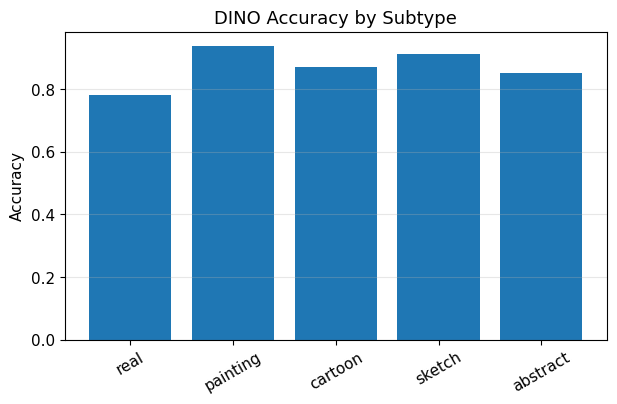

In [26]:
dino_acc = pd.read_csv(RESULTS_NAT / "dino_natural_accuracy_by_subtype.csv")

barplot(
    dino_acc,
    "subtype",
    "accuracy",
    "DINO Accuracy by Subtype",
    "Accuracy",
    order=SUBTYPE_ORDER
)

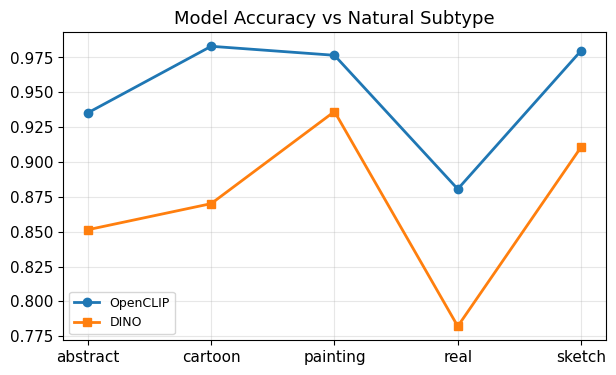

In [27]:
clip = nat_clip_subtype.copy()
eff = nat_eff_subtype.copy()
dino = dino_acc.copy()

plt.figure()

plt.plot(clip["subtype"], clip["accuracy"], marker="o", label="OpenCLIP")
plt.plot(dino["subtype"], dino["accuracy"], marker="s", label="DINO")

plt.grid(True)
plt.legend()
plt.title("Model Accuracy vs Natural Subtype")
plt.show()